# Дизайн и анализ A/B-теста Marketpele

## О проекте

Marketpele размещает в ленте два типа элементов: **платные рекламные объявления** и **органический контент издателей**. Компания рассматривает изменение их расположения, которое потенциально может повлиять на поведение пользователей и выручку платформы.

**Цель проекта** — на основе исторических данных изучить пользовательскую активность и разработать дизайн A/B-теста для проверки предлагаемого изменения. После этого — проанализировать результаты проведённого эксперимента и сформулировать рекомендации для бизнеса.

## Этапы исследования

1. **Предобработка и исследовательский анализ данных (EDA)**
2. **Формирование гипотезы и выбор метрик эксперимента**
3. **Проектирование и валидация дизайна A/B-теста**
4. **Анализ результатов эксперимента**
5. **Формирование выводов и рекомендаций**

In [1]:
#Импорт датасета
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Поддерживаем запуск из корня репозитория и из папки notebooks.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / 'data'

history_path = DATA_DIR / 'user_activity_data.csv'
if not history_path.is_file():
    raise FileNotFoundError(
        f'Добавьте user_activity_data.csv в {DATA_DIR}. См. data/README.md.'
    )

df = pd.read_csv(history_path, sep=',', na_values=[''], quotechar='"')
df.head()

,date,user_id,device,pages_viewed,paid_clicks,organic_clicks,revenue
0,2026-01-01,1,mobile,18,6,0,11.30
1,2026-01-01,4,desktop,6,0,4,5.13
2,2026-01-01,6,desktop,6,2,0,3.89
3,2026-01-01,9,mobile,12,1,12,9.51
4,2026-01-01,11,mobile,15,3,7,13.69


## 1. Предобработка данных

Перед проведением исследовательского анализа проверим структуру датасета, типы данных, наличие пропусков и аномальных значений.

In [2]:
#Смотрим типы столбцов
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 89353 entries, 0 to 89352
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            89353 non-null  str    
 1   user_id         89353 non-null  int64  
 2   device          89353 non-null  str    
 3   pages_viewed    89353 non-null  int64  
 4   paid_clicks     89353 non-null  int64  
 5   organic_clicks  89353 non-null  int64  
 6   revenue         89353 non-null  float64
dtypes: float64(1), int64(4), str(2)
memory usage: 4.8 MB


In [3]:
df['date'] = pd.to_datetime(df['date'])

### Типы данных

Столбец `date` содержит дату наблюдения и был преобразован в формат `datetime`. Типы остальных признаков соответствуют содержащимся в них данным.

In [4]:
#Проверяем пропущенные значения
df.isna().sum()

date              0
user_id           0
device            0
pages_viewed      0
paid_clicks       0
organic_clicks    0
revenue           0
dtype: int64

In [5]:
#Рассмотрим основные характеристики числовых признаков и проверим данные на наличие потенциальных выбросов.
df.describe()

,date,user_id,pages_viewed,paid_clicks,organic_clicks,revenue
count,89353,89353.000000,89353.000000,89353.000000,89353.000000,89353.000000
mean,2026-01-28 12:28:00.077893,1505.003794,14.707173,3.238224,4.533860,15.081812
min,2026-01-01 00:00:00,0.000000,1.000000,0.000000,0.000000,0.520000
25%,2026-01-14 00:00:00,762.000000,9.000000,1.000000,2.000000,9.160000
50%,2026-01-28 00:00:00,1510.000000,14.000000,3.000000,4.000000,11.370000
75%,2026-02-12 00:00:00,2251.000000,19.000000,5.000000,6.000000,13.080000
max,2026-02-25 00:00:00,2999.000000,109.000000,43.000000,44.000000,395.720000
std,NaN,864.196495,8.566596,2.793725,3.485394,31.807689


### Количество пользователей

Одна строка датасета не соответствует одному уникальному пользователю: один пользователь может встречаться в данных несколько раз. Определим количество уникальных пользователей.

In [6]:
df['user_id'].nunique()

3000

Мы выяснили, что в датасете у нас 3000 уникальных пользователей.

In [7]:
#Смотрим распределение данных по девайсам
df['device'].value_counts()

device
mobile     70952
desktop    18401
Name: count, dtype: int64

### Анализ распределений и выбросов

Для выявления потенциальных выбросов рассмотрим распределения основных пользовательских метрик: количества просмотренных страниц, кликов по платным и органическим элементам и выручки.

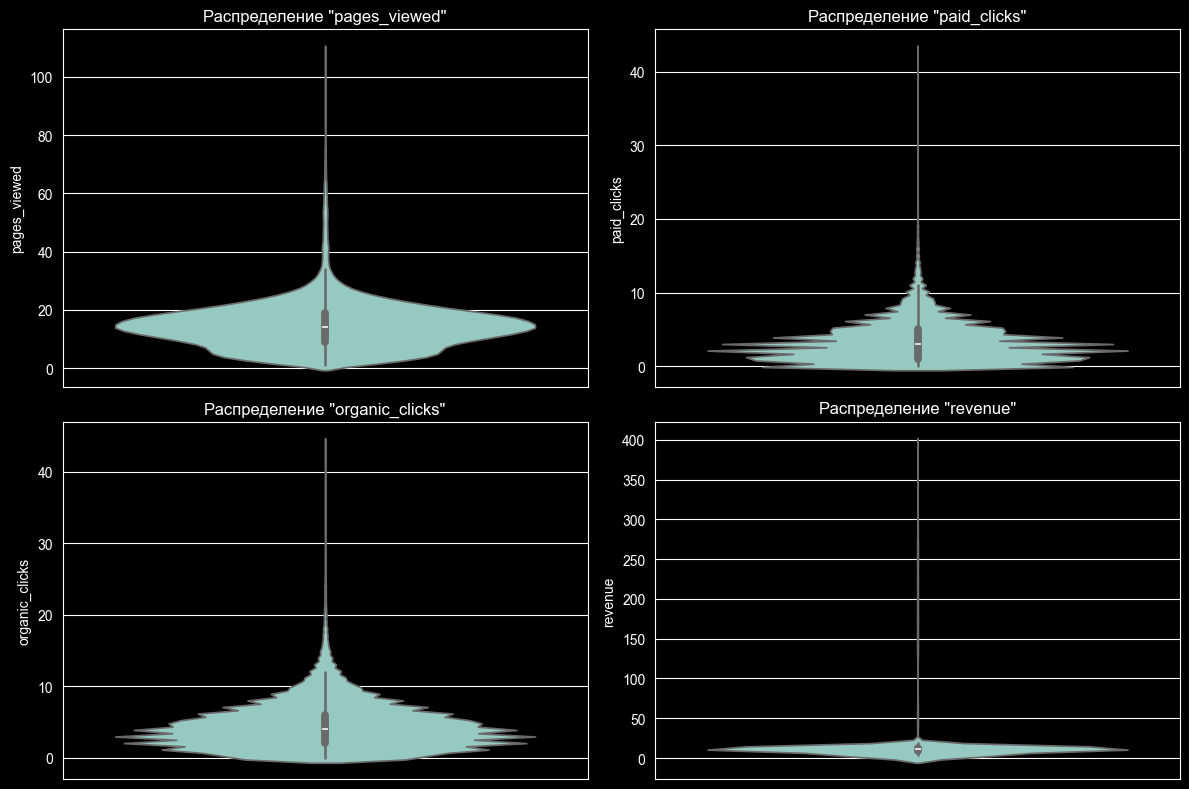

In [8]:
metrics = ['pages_viewed', 'paid_clicks', 'organic_clicks', 'revenue']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes = axes.flatten()

for metric, ax in zip(metrics, axes):
    sns.violinplot(y=df[metric], ax=ax)
    ax.set_title(f'Распределение "{metric}"')
    ax.set_ylabel(metric)

plt.tight_layout()
plt.show()

Все рассматриваемые метрики имеют правостороннюю асимметрию, характерную для метрик пользовательской активности.

Наиболее выраженная асимметрия наблюдается у `revenue`: основная масса значений сосредоточена в узком диапазоне, однако присутствует небольшой набор экстремально высоких наблюдений. Для оценки хвостов распределений рассмотрим верхние квантили метрик.

Большинство пользователей демонстрирует умеренную активность, тогда как небольшая доля пользователей просматривает и кликает значительно больше контента. Такое распределение типично для пользовательских метрик: основная масса пользователей взаимодействует с сервисом ограниченно, а небольшая группа является значительно более активной.

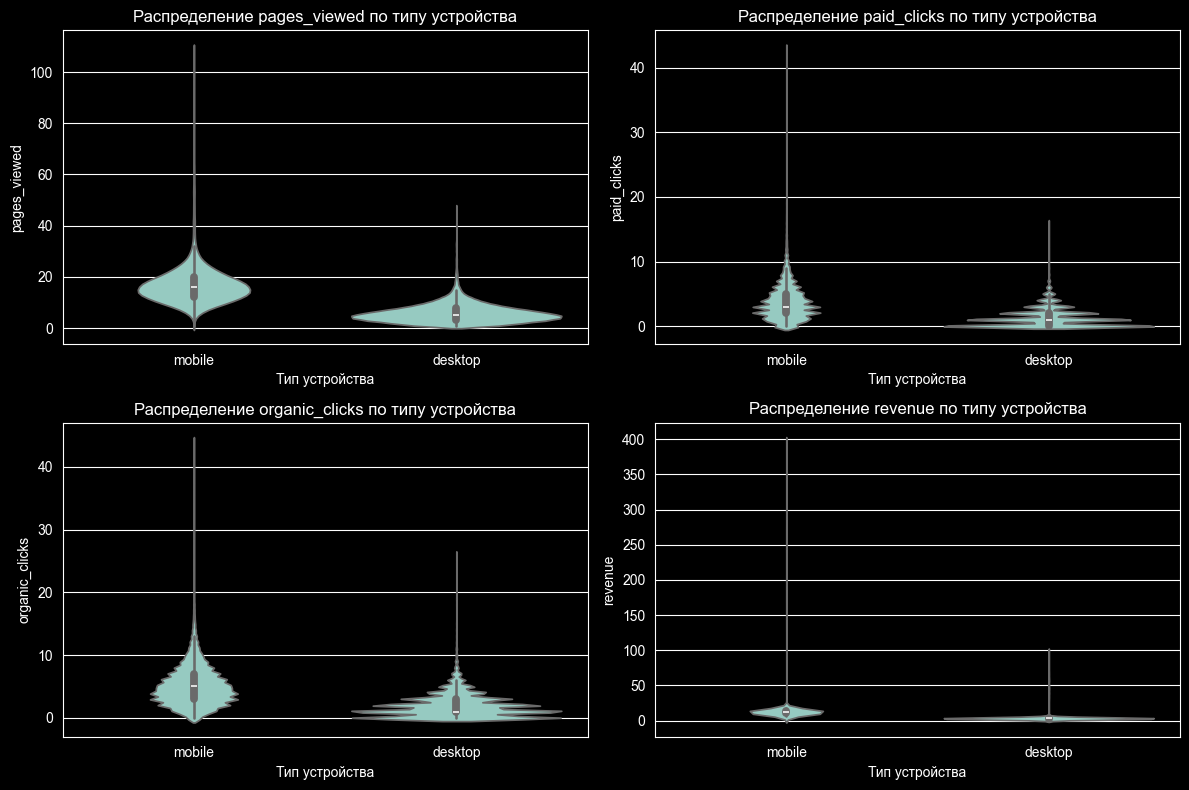

In [9]:
metrics = ['pages_viewed', 'paid_clicks', 'organic_clicks', 'revenue']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for metric, ax in zip(metrics, axes):
    sns.violinplot(
        data=df,
        x='device',
        y=metric,
        ax=ax
    )

    ax.set_title(f'Распределение {metric} по типу устройства')
    ax.set_xlabel('Тип устройства')
    ax.set_ylabel(metric)

plt.tight_layout()
plt.show()

In [10]:
df.groupby('device')[metrics].agg(['mean', 'median']).round(2)

pages_viewed        paid_clicks        organic_clicks        revenue  \
                mean median        mean median           mean median    mean   
device                                                                         
desktop         5.88    5.0        1.27    1.0           1.91    1.0    4.40   
mobile         17.00   16.0        3.75    3.0           5.21    5.0   17.85   

                
        median  
device          
desktop   2.95  
mobile   11.99

### Влияние типа устройства на пользовательские метрики

Между пользователями мобильных и десктопных устройств наблюдаются существенные различия по всем рассматриваемым метрикам.

Пользователи мобильных устройств в среднем просматривают почти в 3 раза больше страниц (`16.99` против `5.88`), совершают примерно в 3 раза больше кликов по рекламным объявлениям (`3.75` против `1.27`) и чаще взаимодействуют с органическим контентом (`5.21` против `1.91`).

Наиболее выраженное различие наблюдается в `revenue`: средняя выручка для mobile составляет `17.85`, тогда как для desktop — `4.40`, то есть примерно в 4 раза меньше.

Схожие различия наблюдаются и при сравнении медиан, поэтому результат нельзя объяснить исключительно влиянием отдельных экстремальных наблюдений.

Таким образом, тип устройства является важным фактором, связанным как с пользовательской активностью, так и с выручкой. При проектировании A/B-теста необходимо учитывать различия между mobile и desktop, поскольку дисбаланс долей устройств между экспериментальными группами может повлиять на итоговые метрики независимо от эффекта тестируемого изменения.

In [11]:
quantiles2 = [0.95, 0.96, 0.97, 0.98, 0.99]

In [12]:
metrics = ['pages_viewed', 'paid_clicks', 'organic_clicks', 'revenue']
quantiles = [0.90, 0.95, 0.99, 0.995, 0.999]
df[metrics].quantile(quantiles)

,pages_viewed,paid_clicks,organic_clicks,revenue
0.900,23.0,7.0,9.0,14.7700
0.950,27.0,8.0,11.0,16.1900
0.990,50.0,12.0,16.0,221.8900
0.995,59.0,14.0,19.0,261.7124
0.999,75.0,21.0,28.0,306.5592


Для `pages_viewed`, `paid_clicks` и `organic_clicks` значения верхних квантилей увеличиваются относительно плавно.

Для `revenue` наблюдается иная картина: 95-й перцентиль составляет 16.19, тогда как 99-й — уже 221.89. Это указывает на наличие небольшой доли наблюдений с экстремально высокой выручкой.

Для более точного определения области резкого изменения распределения рассмотрим промежуточные квантили `revenue`.

In [13]:
quantiles2 = [0.95, 0.96, 0.97, 0.98, 0.99]
df['revenue'].quantile(quantiles2)

0.95     16.1900
0.96     16.8300
0.97     19.1544
0.98    143.7224
0.99    221.8900
Name: revenue, dtype: float64

До 97-го перцентиля значения `revenue` растут относительно плавно: значение 97-го перцентиля составляет 19.15. Между 97-м и 98-м перцентилями происходит резкий скачок до 143.72.

Дополнительно рассмотрим наблюдения с высокой выручкой, чтобы проверить, связаны ли экстремальные значения с повышенной пользовательской активностью.

In [14]:
df[df['revenue'] > 20].head()

,date,user_id,device,pages_viewed,paid_clicks,organic_clicks,revenue
10,2026-01-01,23,mobile,8,3,6,242.26
126,2026-01-01,240,mobile,24,2,2,248.37
131,2026-01-01,252,mobile,7,5,4,137.72
133,2026-01-01,254,desktop,2,1,3,56.59
195,2026-01-01,373,mobile,20,4,5,150.84


Экстремальные значения `revenue` встречаются при обычных значениях просмотров и кликов и не сопровождаются пропорциональным ростом пользовательской активности.

Для снижения влияния экстремальных значений на дисперсию метрики в качестве порога очистки используется 97-й перцентиль `revenue`.

In [15]:
revenue_threshold = df['revenue'].quantile(0.97)

In [16]:
df_clean = df[df['revenue'] <= revenue_threshold].copy()

In [17]:
df_clean.describe()

,date,user_id,pages_viewed,paid_clicks,organic_clicks,revenue
count,86672,86672.000000,86672.000000,86672.000000,86672.000000,86672.000000
mean,2026-01-28 12:25:28.189034,1505.459168,14.702072,3.236593,4.532086,10.161643
min,2026-01-01 00:00:00,0.000000,1.000000,0.000000,0.000000,0.520000
25%,2026-01-14 00:00:00,762.000000,9.000000,1.000000,2.000000,9.020000
50%,2026-01-29 00:00:00,1511.000000,14.000000,3.000000,4.000000,11.280000
75%,2026-02-12 00:00:00,2251.000000,19.000000,5.000000,6.000000,12.900000
max,2026-02-25 00:00:00,2999.000000,109.000000,43.000000,44.000000,19.150000
std,NaN,864.483670,8.560387,2.797246,3.481959,4.080836


### Результат обработки выбросов

После удаления наблюдений выше 97-го перцентиля `revenue`:

- количество наблюдений сократилось с **89 353 до 86 672** (примерно на 3%);
- среднее значение `revenue` снизилось с **15.08 до 10.16**;
- медиана практически не изменилась: **11.37 → 11.28**;
- стандартное отклонение снизилось с **31.81 до 4.08**.

Таким образом, небольшая доля экстремальных наблюдений оказывала существенное влияние на среднее значение и дисперсию `revenue`, практически не влияя на медиану. Для дальнейшего анализа используется очищенный датасет `df_clean`.

### Период наблюдений и ежедневная активность

Определим временной охват очищенных данных и число активных пользователей по дням. Это поможет оценить доступную аудиторию для эксперимента.

In [18]:
print(f"Данные в датасете представлены за период от {df_clean['date'].min().date()} до {df_clean['date'].max().date()}")

Данные в датасете представлены за период от 2026-01-01 до 2026-02-25


In [19]:
daily_users = (
    df_clean.groupby('date')['user_id']
    .nunique()
)

daily_users.head()

date
2026-01-01    1569
2026-01-02    1550
2026-01-03    1551
2026-01-04    1505
2026-01-05    1585
Name: user_id, dtype: int64

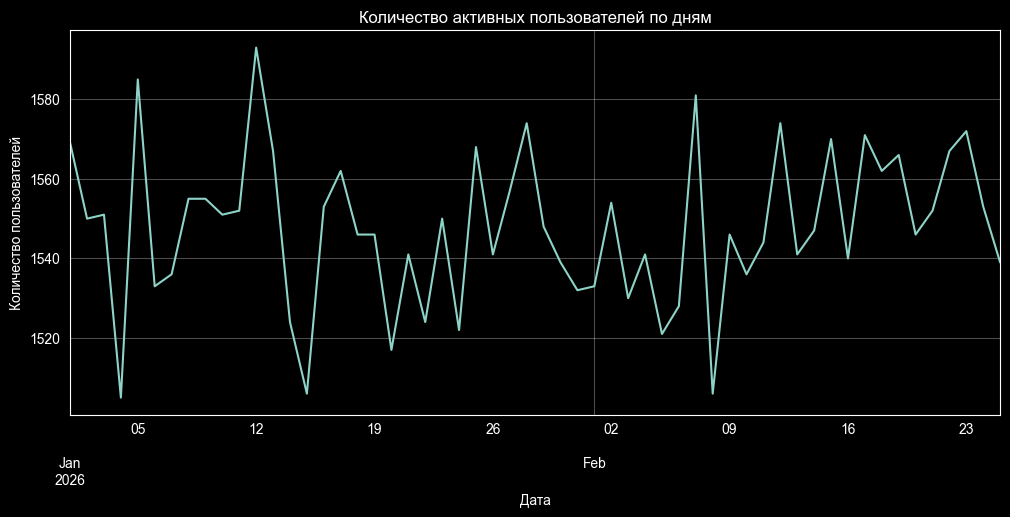

In [20]:
plt.figure(figsize=(12, 5))

daily_users.plot()

plt.title('Количество активных пользователей по дням')
plt.xlabel('Дата')
plt.ylabel('Количество пользователей')
plt.grid(alpha=0.3)

plt.show()

### Активность пользователей

Ежедневно платформой пользуются примерно 1.5–1.6 тыс. уникальных пользователей. На протяжении рассматриваемого периода количество активных пользователей остаётся относительно стабильным: выраженного восходящего или нисходящего тренда не наблюдается.

При этом общее количество уникальных пользователей в датасете составляет 3000, что указывает на повторную активность одних и тех же пользователей в разные дни. Это необходимо учитывать при дальнейшем расчёте параметров A/B-теста.

In [21]:
user_activity = (
    df_clean.groupby('user_id')['date']
    .nunique()
)

In [22]:
user_activity.describe()

count    3000.000000
mean       28.890667
std        15.106824
min         2.000000
25%        16.000000
50%        29.000000
75%        42.000000
max        56.000000
Name: date, dtype: float64

#### Частота активности пользователей

Пользователи регулярно возвращаются на платформу в течение рассматриваемого периода. Медианный пользователь был активен **29 из 56 дней**, а среднее количество активных дней составляет **28.9**.

При этом наблюдается заметная неоднородность активности: четверть пользователей была активна не более 16 дней, тогда как наиболее активная четверть — не менее 42 дней. Некоторые пользователи присутствовали в данных на протяжении всех 56 дней.

Таким образом, наблюдения одного пользователя в разные дни нельзя рассматривать как независимых пользователей. При проектировании A/B-теста рандомизацию следует проводить на уровне `user_id`, закрепляя пользователя за одной экспериментальной группой на весь период теста.

In [23]:
df_clean['ctr_paid'] = df_clean['paid_clicks'] / df_clean['pages_viewed']

df_clean['ctr_organic'] = df_clean['organic_clicks'] / df_clean['pages_viewed']

In [24]:
df_clean[['ctr_paid', 'ctr_organic']].describe()

,ctr_paid,ctr_organic
count,86672.000000,86672.000000
mean,0.275413,0.390899
std,0.346964,0.448502
min,0.000000,0.000000
25%,0.090909,0.153846
50%,0.200000,0.285714
75%,0.352941,0.500000
max,12.000000,11.000000


In [25]:
df_clean.groupby('device')[['ctr_paid', 'ctr_organic']].agg(
    ['mean', 'median']
)

ctr_paid           ctr_organic          
             mean    median        mean    median
device                                           
desktop  0.334076  0.166667    0.500199  0.285714
mobile   0.260179  0.200000    0.362514  0.291667

### Конверсия просмотров в клики

Для оценки интенсивности взаимодействия с контентом рассчитаны две дополнительные метрики:

- `ctr_paid` — отношение количества кликов по платным объявлениям к количеству просмотренных страниц;
- `ctr_organic` — отношение количества кликов по органическому контенту к количеству просмотренных страниц.

Поскольку одна просмотренная страница может содержать несколько элементов и приводить к нескольким кликам, значения рассчитанных показателей могут превышать 1. Поэтому далее они интерпретируются как **количество кликов на просмотр страницы**, а не как классический CTR по показам рекламных элементов.

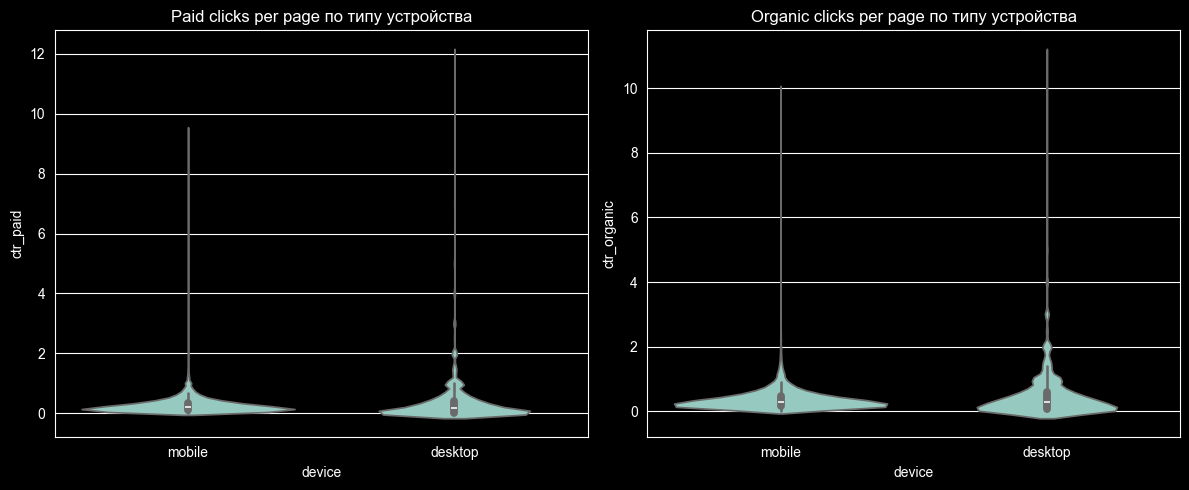

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.violinplot(
    data=df_clean,
    x='device',
    y='ctr_paid',
    ax=axes[0]
)
axes[0].set_title('Paid clicks per page по типу устройства')

sns.violinplot(
    data=df_clean,
    x='device',
    y='ctr_organic',
    ax=axes[1]
)
axes[1].set_title('Organic clicks per page по типу устройства')

plt.tight_layout()
plt.show()

### Закономерности в конверсиях

Распределения `ctr_paid` и `ctr_organic` имеют выраженную правостороннюю асимметрию и содержат редкие высокие значения.

Средние значения обеих метрик выше для desktop-пользователей, однако медианные значения для mobile и desktop близки. Это указывает на то, что различия средних во многом связаны с небольшим количеством наблюдений в правом хвосте распределения.

Таким образом, значительно большее абсолютное количество кликов у mobile-пользователей в первую очередь связано с большим количеством просмотренных страниц, а не с более высокой интенсивностью кликов на одну просмотренную страницу.

In [27]:
corr_metrics = [
    'pages_viewed',
    'paid_clicks',
    'organic_clicks',
    'revenue',
    'ctr_paid',
    'ctr_organic'
]

corr_matrix = df_clean[corr_metrics].corr()

corr_matrix

,pages_viewed,paid_clicks,organic_clicks,revenue,ctr_paid,ctr_organic
pages_viewed,1.000000,0.195092,0.203855,0.468462,-0.273577,-0.316446
paid_clicks,0.195092,1.000000,0.143838,0.318658,0.541046,-0.045391
organic_clicks,0.203855,0.143838,1.000000,0.339087,-0.033079,0.498859
revenue,0.468462,0.318658,0.339087,1.000000,-0.078108,-0.112761
ctr_paid,-0.273577,0.541046,-0.033079,-0.078108,1.000000,0.268019
ctr_organic,-0.316446,-0.045391,0.498859,-0.112761,0.268019,1.000000


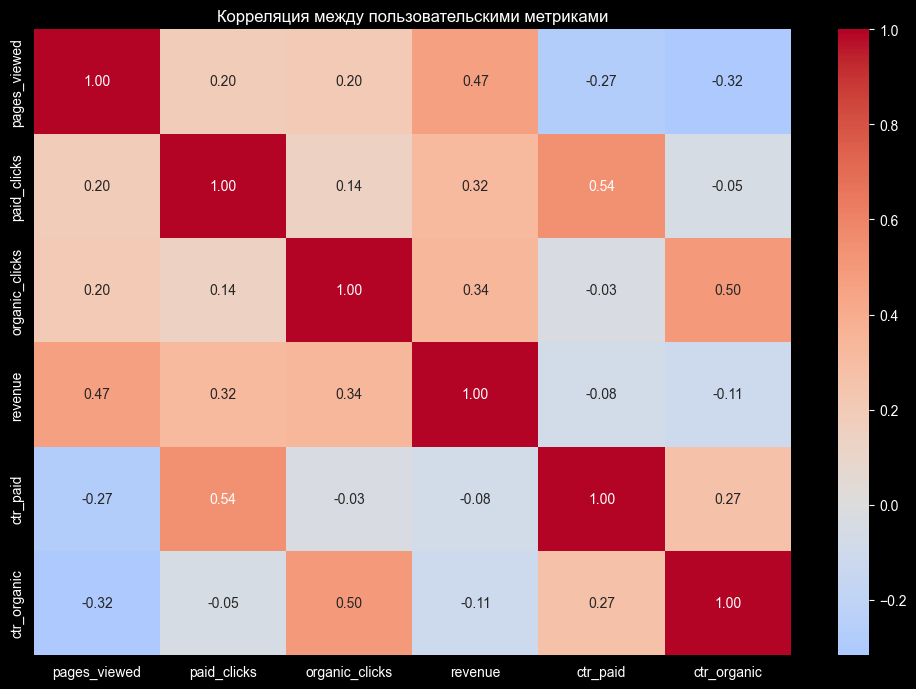

In [28]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Корреляция между пользовательскими метриками')
plt.tight_layout()
plt.show()

### Корреляции между метриками

Корреляционный анализ показывает умеренную положительную связь между `revenue` и пользовательской активностью. Наиболее выраженная связь наблюдается между выручкой и количеством просмотренных страниц (`r = 0.47`). Связь выручки с платными (`r = 0.32`) и органическими (`r = 0.34`) кликами несколько слабее.

Количество соответствующих кликов положительно связано с рассчитанными показателями конверсии: `paid_clicks` и `ctr_paid` имеют корреляцию `0.54`, а `organic_clicks` и `ctr_organic` — `0.50`.

Между количеством просмотренных страниц и показателями конверсии наблюдается отрицательная корреляция (`-0.27` для `ctr_paid` и `-0.32` для `ctr_organic`). При интерпретации этой связи необходимо учитывать, что `pages_viewed` непосредственно входит в знаменатель обеих метрик конверсии, поэтому отрицательная связь может быть частично обусловлена способом их расчёта.

В целом наиболее заметно с выручкой связана общая пользовательская активность, выраженная количеством просмотренных страниц.

# 2. Дизайн A/B-теста

## Бизнес-контекст

Лента Marketplace содержит два типа элементов:

- **платные элементы** - рекламные объявления, переходы по которым приносят платформе доход;
- **органические элементы** - контент издателей, позволяющий пользователям переходить к другим материалам внутри платформы.

Предполагается изменить расположение платных и органических элементов в ленте. Изменение может повлиять на взаимодействие пользователей с обоими типами контента и, как следствие, на выручку Marketplace.

### Бизнес-цель

Цель эксперимента - определить, позволит ли новое расположение элементов **увеличить выручку Marketplace**, не оказывая при этом существенного негативного влияния на взаимодействие пользователей с органическим контентом.

При оценке результатов важно учитывать не только изменение выручки, но и пользовательские метрики. Рост монетизации, сопровождающийся существенным ухудшением взаимодействия с основным контентом платформы, может иметь негативные долгосрочные последствия.

Таким образом, A/B-тест должен позволить оценить как **экономический эффект изменения**, так и его влияние на пользовательское поведение.

## Гипотеза эксперимента

**Продуктовая гипотеза:** если изменить расположение платных и органических элементов, пользователи будут активнее взаимодействовать с платными элементами, что приведёт к росту выручки Marketpele.

### Метрики эксперимента

- **Основная метрика — `revenue`**
  Отражает прямой бизнес-эффект изменения и используется для принятия итогового решения по эксперименту.

- **Прокси-метрика — `ctr_paid`**
  Позволяет оценить, изменилось ли взаимодействие пользователей с платными элементами и помогает объяснить возможное изменение выручки.

- **Guardrail-метрика — `ctr_organic`**
  Используется для контроля негативного влияния нового расположения элементов на взаимодействие пользователей с органическим контентом.

### Статистические гипотезы

Для основной метрики `revenue` проверяется односторонняя гипотеза:

- **H₀:** новое расположение элементов не увеличивает среднюю выручку пользователя.
- **H₁:** новое расположение элементов увеличивает среднюю выручку пользователя.

### Уровень значимости и мощность теста

Для эксперимента принимаются следующие параметры:

- **уровень значимости `α = 0.05`**;
- **мощность теста `1 - β = 0.80`**.

Уровень значимости 5% означает, что мы допускаем вероятность ошибки первого рода не более 5% — то есть риск сделать вывод о наличии положительного эффекта, когда его на самом деле нет.

Мощность 80% означает, что при наличии эффекта заданного размера тест должен обнаружить его примерно в 80% случаев.

### Выбор длительности эксперимента

Сравним исторические периоды длительностью **14, 21 и 28 дней**. Для каждого периода рассчитаем суммарную выручку на пользователя: единицей анализа будет `user_id`.

In [29]:
df_clean[
    (df_clean['date'] >= df_clean['date'].min()) &
    (df_clean['date'] <= df_clean['date'].min() + pd.Timedelta(days=13))
]['user_id'].nunique()

2914

In [30]:
days14 = df_clean[
    (df_clean['date'] >= df_clean['date'].min()) &
    (df_clean['date'] <= df_clean['date'].min() + pd.Timedelta(days=13))
]

In [31]:
# 21 день
days21 = df_clean[
    (df_clean['date'] >= df_clean['date'].min()) &
    (df_clean['date'] <= df_clean['date'].min() + pd.Timedelta(days=20))
]

In [32]:
# 28 дней
days28 = df_clean[
    (df_clean['date'] >= df_clean['date'].min()) &
    (df_clean['date'] <= df_clean['date'].min() + pd.Timedelta(days=27))
]

In [33]:
revenue14 = days14.groupby('user_id')['revenue'].agg(
    ['sum']
)

In [34]:
revenue14.describe()

,sum
count,2914.000000
mean,75.791208
std,50.817463
min,1.060000
25%,30.072500
50%,67.705000
75%,117.922500
max,220.820000


### Расчёт минимального детектируемого эффекта

Оценим **MDE** — размер роста средней выручки, который тест сможет обнаруживать с заданной мощностью. Используем разбивку 50/50, стандартную ошибку разности средних и квантили нормального распределения для одностороннего теста.

In [35]:
std = revenue14['sum'].std()

n_a = 2914 // 2
n_b = 2914 - n_a

se = std * np.sqrt(1 / n_a + 1 / n_b)

se

np.float64(1.8827740382364615)

In [36]:
from scipy.stats import norm

alpha = 0.05
power = 0.80

z_alpha = norm.ppf(1 - alpha)
z_beta = norm.ppf(power)

z_alpha, z_beta

(np.float64(1.6448536269514722), np.float64(0.8416212335729143))

In [37]:
mde = (z_alpha + z_beta) * se

mde

np.float64(4.681470314122941)

In [38]:
mean_revenue = revenue14['sum'].mean()

mde_relative = mde / mean_revenue

mde_relative

np.float64(0.061767986551909855)

In [39]:
revenue21 = days21.groupby('user_id')['revenue'].agg(['sum'])
revenue28 = days28.groupby('user_id')['revenue'].agg(['sum'])

In [40]:
revenue28.describe()

,sum
count,2987.000000
mean,147.531108
std,100.278983
min,1.430000
25%,58.195000
50%,132.660000
75%,232.160000
max,429.510000


In [41]:
revenue21.describe()

,sum
count,2961.000000
mean,111.718200
std,75.599633
min,1.570000
25%,44.550000
50%,99.880000
75%,175.320000
max,323.260000


In [42]:
def calculate_mde(revenue_data, alpha=0.05, power=0.80):
    n = len(revenue_data)

    n_a = n // 2
    n_b = n - n_a

    mean_revenue = revenue_data['sum'].mean()
    std_revenue = revenue_data['sum'].std()

    se = std_revenue * np.sqrt(1 / n_a + 1 / n_b)

    z_alpha = norm.ppf(1 - alpha)
    z_beta = norm.ppf(power)

    mde_abs = (z_alpha + z_beta) * se
    mde_rel = mde_abs / mean_revenue

    return {
        'users': n,
        'users_per_group': min(n_a, n_b),
        'mean_revenue': mean_revenue,
        'std_revenue': std_revenue,
        'mde_abs': mde_abs,
        'mde_percent': mde_rel * 100
    }

In [43]:
mde_14 = calculate_mde(revenue14)
mde_21 = calculate_mde(revenue21)
mde_28 = calculate_mde(revenue28)

In [44]:
design_table = pd.DataFrame(
    [mde_14, mde_21, mde_28],
    index=['14 дней', '21 день', '28 дней']
).round(2)

design_table

,users,users_per_group,mean_revenue,std_revenue,mde_abs,mde_percent
14 дней,2914,1457,75.79,50.82,4.68,6.18
21 день,2961,1480,111.72,75.60,6.91,6.18
28 дней,2987,1493,147.53,100.28,9.12,6.18


### Сравнение вариантов дизайна

При увеличении периода с 14 до 28 дней число пользователей растёт с **2914 до 2987**, а относительный MDE остаётся около **6.18%**. По этим расчётам продление теста почти не улучшает чувствительность; далее проверим 14-дневный вариант с помощью симуляций.

In [45]:
# Случайно выбираем половину пользователей в группу A
group_a = revenue14.sample(frac=0.5, random_state=42)

# Все остальные пользователи попадают в группу B
group_b = revenue14.drop(group_a.index)

In [47]:
#Проводим один AA-тест

from scipy.stats import ttest_ind

result = ttest_ind(
    group_a['sum'],
    group_b['sum'],
    alternative='less'
)

result

TtestResult(statistic=np.float64(0.940101666283683), pvalue=np.float64(0.826378306081194), df=np.float64(2912.0))

В одном A/A-разбиении получено **p-value = 0.826**: значимых различий не обнаружено. Чтобы оценить частоту ложных срабатываний, повторим случайное разбиение **1000 раз**.

In [48]:
pvalues = []

for i in range(1000):
    group_a = revenue14.sample(frac=0.5, random_state=i)
    group_b = revenue14.drop(group_a.index)

    result = ttest_ind(
        group_a['sum'],
        group_b['sum'],
        alternative='less'
    )

    pvalues.append(result.pvalue)

In [49]:
fpr = np.mean(np.array(pvalues) < 0.05)

fpr

np.float64(0.056)

### Валидация дизайна: A/A-тест

Для проверки корректности статистического критерия проведено 1000 симуляций A/A-теста. На каждой итерации пользователи случайным образом разделялись на две группы без добавления искусственного эффекта, после чего сравнивалась средняя выручка на пользователя.

Доля ложноположительных результатов составила **5.6%**, что близко к заданному уровню значимости **α = 5%**.

Таким образом, выбранный статистический критерий корректно контролирует ошибку первого рода.

### Симуляция эффекта

Искусственно увеличим выручку группы B на **6.18%** и проверим, как часто тест обнаруживает этот рост. Один запуск не оценивает мощность, поэтому затем повторим процедуру на 1000 разбиениях.

In [50]:
mde_relative = 0.0618

group_b_effect = group_b.copy()
group_b_effect['sum'] = group_b_effect['sum'] * (1 + mde_relative)

In [51]:
result = ttest_ind(
    group_a['sum'],
    group_b_effect['sum'],
    alternative='less'
)

result

TtestResult(statistic=np.float64(-1.3951904568449127), pvalue=np.float64(0.08153240332375504), df=np.float64(2912.0))

In [52]:
pvalues_ab = []

for i in range(1000):
    group_a = revenue14.sample(frac=0.5, random_state=i)
    group_b = revenue14.drop(group_a.index)

    group_b_effect = group_b.copy()
    group_b_effect['sum'] = group_b_effect['sum'] * (1 + mde_relative)

    result = ttest_ind(
        group_a['sum'],
        group_b_effect['sum'],
        alternative='less'
    )

    pvalues_ab.append(result.pvalue)

In [53]:
power_simulated = np.mean(np.array(pvalues_ab) < 0.05)

power_simulated

np.float64(0.801)

### Валидация мощности дизайна

Для проверки рассчитанного MDE проведено 1000 симуляций A/B-теста. На каждой итерации пользователи случайным образом разделялись на контрольную и тестовую группы, после чего в тестовую группу искусственно добавлялся эффект, равный рассчитанному MDE — **6.18%**.

Статистически значимый рост выручки был обнаружен в **80.1%** симуляций, что практически совпадает с заданной мощностью теста **80%**.

Таким образом, симуляция подтверждает корректность рассчитанного MDE для 14-дневного дизайна.

In [55]:
def validate_design(revenue_data, mde_relative, alpha=0.05, n_simulations=1000):

    pvalues_aa = []
    pvalues_ab = []

    for i in range(n_simulations):

        # Случайно делим пользователей на две группы
        group_a = revenue_data.sample(frac=0.5, random_state=i)
        group_b = revenue_data.drop(group_a.index)

        # A/A-тест
        result_aa = ttest_ind(
            group_a['sum'],
            group_b['sum'],
            alternative='less'
        )

        pvalues_aa.append(result_aa.pvalue)

        # Искусственно добавляем эффект в группу B
        group_b_effect = group_b.copy()
        group_b_effect['sum'] *= (1 + mde_relative)

        # A/B-тест
        result_ab = ttest_ind(
            group_a['sum'],
            group_b_effect['sum'],
            alternative='less'
        )

        pvalues_ab.append(result_ab.pvalue)

    # Доля ложноположительных результатов
    fpr = np.mean(np.array(pvalues_aa) < alpha)

    # Доля случаев, когда обнаружили реальный эффект
    simulated_power = np.mean(np.array(pvalues_ab) < alpha)

    return fpr, simulated_power

In [57]:
mde_14_rel = mde_14['mde_percent'] / 100
mde_21_rel = mde_21['mde_percent'] / 100
mde_28_rel = mde_28['mde_percent'] / 100

In [58]:
validation_14 = validate_design(revenue14, mde_14_rel)
validation_21 = validate_design(revenue21, mde_21_rel)
validation_28 = validate_design(revenue28, mde_28_rel)

In [59]:
validation_14, validation_21, validation_28

((np.float64(0.056), np.float64(0.801)),
 (np.float64(0.047), np.float64(0.78)),
 (np.float64(0.048), np.float64(0.755)))

### Подготовка данных для CUPED

В симуляциях для 14, 21 и 28 дней мощность составила **80.1%, 78.0% и 75.5%** соответственно. Увеличение длительности не дало преимущества.

Теперь оценим снижение дисперсии с помощью CUPED на исторических данных: первые 14 дней используем как предэкспериментальный период, следующие 14 — как условный экспериментальный. Объединим выручку по `user_id`; отсутствие записей в одном из периодов здесь трактуется как нулевая выручка.

In [60]:
days15_28 = df_clean[
    (df_clean['date'] >= df_clean['date'].min() + pd.Timedelta(days=14)) &
    (df_clean['date'] <= df_clean['date'].min() + pd.Timedelta(days=27))
]

In [61]:
revenue15_28 = (
    days15_28
    .groupby('user_id')['revenue']
    .sum()
)

In [62]:
cuped_data = pd.concat(
    [revenue14['sum'], revenue15_28],
    axis=1,
    keys=['revenue_pre', 'revenue_exp']
)

In [63]:
cuped_data = cuped_data.fillna(0)

In [64]:
cuped_data.head()

,revenue_pre,revenue_exp
user_id,,
0,162.91,169.76
1,123.59,115.53
2,39.88,35.01
4,15.39,14.67
5,2.92,6.00


In [65]:
cuped_data.corr()

,revenue_pre,revenue_exp
revenue_pre,1.000000,0.883262
revenue_exp,0.883262,1.000000


### Корректировка выручки

Рассчитаем коэффициент `theta` и вычтем из выручки компоненту, связанную с активностью пользователя в предыдущем периоде. Затем сравним разброс исходной и скорректированной метрик и пересчитаем MDE.

In [66]:
covariance = cuped_data['revenue_pre'].cov(
    cuped_data['revenue_exp']
)

variance = cuped_data['revenue_pre'].var()

theta = covariance / variance

theta

np.float64(0.8877515693076553)

In [67]:
cuped_data['revenue_cuped'] = (
    cuped_data['revenue_exp']
    - theta * (
        cuped_data['revenue_pre']
        - cuped_data['revenue_pre'].mean()
    )
)

In [68]:
cuped_data[['revenue_exp', 'revenue_cuped']].describe()

,revenue_exp,revenue_cuped
count,2987.000000,2987.000000
mean,73.592179,73.592179
std,51.801098,24.288473
min,0.000000,-15.295828
25%,27.320000,59.793619
50%,65.250000,71.142924
75%,116.690000,87.804870
max,214.820000,166.134707


In [69]:
std_cuped = cuped_data['revenue_cuped'].std()

In [70]:
n = len(cuped_data)

n_a = n // 2
n_b = n - n_a

In [71]:
se_cuped = std_cuped * np.sqrt(1 / n_a + 1 / n_b)

mde_cuped = (z_alpha + z_beta) * se_cuped

mde_cuped_relative = (
    mde_cuped / cuped_data['revenue_cuped'].mean()
)

mde_cuped_relative * 100

np.float64(3.0030670363113554)

### Применение CUPED

В качестве ковариаты использована выручка пользователя за предэкспериментальный период. Корреляция между выручкой до эксперимента и выручкой в экспериментальном периоде составила **0.88**, что указывает на сильную связь между метриками.

После применения CUPED стандартное отклонение целевой метрики снизилось с **51.80 до 24.29**, при этом среднее значение осталось неизменным.

Использование CUPED позволило снизить относительный MDE примерно до **3.0%**. Таким образом, CUPED существенно повышает чувствительность эксперимента и позволяет обнаруживать меньшие изменения выручки при том же объёме выборки.

# Итоговый дизайн A/B-теста

По результатам анализа исторических данных, расчёта MDE и проведения симуляций был сформирован итоговый дизайн эксперимента.

## 1. Длительность эксперимента

Планируемая длительность A/B-теста — **14 дней**.

Исторические данные показывают, что за 14 дней в эксперимент попадает около **2914 уникальных пользователей**. Увеличение продолжительности теста до 21–28 дней приводит лишь к небольшому увеличению числа уникальных пользователей, поэтому проведение более длительного эксперимента не даёт существенного преимущества с точки зрения набора аудитории.

## 2. Распределение трафика

Пользователи будут случайным образом распределены между двумя группами в пропорции **50/50**:

- **Группа A (контрольная)** — текущий вариант расположения платных и органических элементов;
- **Группа B (тестовая)** — новый вариант расположения элементов.

При ожидаемом объёме выборки около 2914 пользователей в каждую группу попадёт приблизительно **1457 пользователей**.

Разделение проводится на уровне `user_id`: один пользователь может находиться только в одной экспериментальной группе на протяжении всего теста.

## 3. Метрики эксперимента

### Основная метрика

**Revenue per user** — суммарная выручка на пользователя за период эксперимента.

Основной целью изменения является увеличение выручки, поэтому именно эта метрика используется для принятия итогового решения по результатам A/B-теста.

### Прокси-метрика

**CTR paid** — отношение количества кликов по платным элементам к количеству просмотренных страниц.

Метрика позволяет проверить предполагаемый механизм воздействия: изменение расположения элементов должно увеличить взаимодействие пользователей с платными элементами.

### Guardrail-метрика

**CTR organic** — отношение количества кликов по органическим элементам к количеству просмотренных страниц.

Метрика используется для контроля возможного негативного эффекта. Рост выручки и CTR платных элементов не должен происходить за счёт существенного ухудшения взаимодействия пользователей с органическими элементами.

## 4. MDE

Для расчёта минимального детектируемого эффекта используются следующие параметры:

- уровень значимости **α = 0.05**;
- статистическая мощность **80%**;
- односторонняя альтернативная гипотеза;
- распределение пользователей между группами **50/50**.

Для 14-дневного эксперимента без применения методов снижения дисперсии относительный MDE для выручки составляет около **6.18%**.

Проведённая симуляция A/B-теста показала мощность около **80.1%**, что соответствует заложенному при расчёте уровню мощности.

Дополнительно проведён A/A-тест: доля ложноположительных результатов составила **5.6%**, что близко к заданному уровню значимости 5%.

## 5. Применение CUPED

Для повышения чувствительности эксперимента планируется использовать **CUPED**.

В качестве ковариаты используется выручка пользователя за предэкспериментальный 14-дневный период.

Корреляция между выручкой пользователя в предэкспериментальном и последующем периодах составляет около **0.88**, что свидетельствует о сильной связи между показателями и делает историческую выручку подходящей ковариатой.

После применения CUPED стандартное отклонение метрики снизилось с **51.80 до 24.29**, при этом среднее значение осталось неизменным.

В результате относительный MDE снизился примерно до **3.0%**.

Таким образом, применение CUPED целесообразно: метод существенно снижает дисперсию целевой метрики и позволяет обнаруживать меньшие изменения выручки при том же объёме выборки.

## 6. Обработка выбросов

В ходе EDA в распределении `revenue` была обнаружена отдельная группа аномально высоких значений. Начиная примерно с **98-го перцентиля** наблюдался резкий скачок выручки, не сопровождавшийся сопоставимым изменением остальных пользовательских метрик.

Для снижения влияния этих наблюдений на среднее значение и дисперсию из исторических данных были исключены наблюдения выше **97-го перцентиля `revenue`**.

Аналогичный подход к обработке выбросов должен быть зафиксирован **до начала анализа результатов A/B-теста** и одинаково применяться к обеим экспериментальным группам, чтобы решение об удалении наблюдений не зависело от результатов эксперимента.

## 7. Гипотеза

### Продуктовая гипотеза

Если изменить расположение платных и органических элементов, пользователи будут активнее взаимодействовать с платными элементами, что приведёт к росту выручки.

### Статистическая гипотеза

Поскольку для бизнеса представляет интерес именно увеличение выручки, используется **односторонняя статистическая гипотеза**.

**Нулевая гипотеза (H₀):**

Средняя выручка на пользователя в тестовой группе не превышает среднюю выручку в контрольной группе:

$$
H_0: \mu_B \leq \mu_A
$$

**Альтернативная гипотеза (H₁):**

Средняя выручка на пользователя в тестовой группе выше, чем в контрольной:

$$
H_1: \mu_B > \mu_A
$$

Уровень статистической значимости:

$$
\alpha = 0.05
$$

Статистическая мощность:

$$
1-\beta = 0.80
$$

## Итог

Для проведения эксперимента выбран **14-дневный A/B-тест с распределением трафика 50/50**. Основной метрикой является выручка на пользователя, прокси-метрикой — CTR платных элементов, guardrail-метрикой — CTR органических элементов.

Для повышения чувствительности эксперимента применяется **CUPED с исторической выручкой пользователя в качестве ковариаты**. Ожидаемый относительный MDE после снижения дисперсии составляет около **3%**.

Решение о внедрении изменения принимается при наличии статистически значимого роста основной метрики при отсутствии неприемлемого ухудшения guardrail-метрики.

# 3. Анализ результатов A/B-теста

Загрузим данные проведённого эксперимента, проверим их структуру и состав групп. В этом разделе анализируется исходная выручка: CUPED выше использовался при проектировании на исторических данных, а к результатам эксперимента здесь не применяется.

In [72]:
experiment_path = DATA_DIR / 'experiment_data.csv'
if not experiment_path.is_file():
    raise FileNotFoundError(
        f'Добавьте experiment_data.csv в {DATA_DIR}. См. data/README.md.'
    )

experiment_data = pd.read_csv(experiment_path, sep=',', na_values=[''], quotechar='"')
experiment_data.head()

,user_id,pages_viewed,paid_clicks,organic_clicks,revenue,device,ctr_paid,ctr_organic,group
0,1,61,15,10,35.06,mobile,0.245902,0.163934,control
1,2,213,57,114,179.21,mobile,0.267606,0.535211,control
2,5,23,3,13,13.75,desktop,0.130435,0.565217,control
3,8,356,30,182,271.25,mobile,0.084270,0.511236,control
4,9,226,25,45,418.44,mobile,0.110619,0.199115,control
...,...,...,...,...,...,...,...,...,...
1978,1986,140,62,55,119.84,mobile,0.492108,0.304406,test
1979,1989,120,59,48,156.06,mobile,0.558156,0.305039,test
1980,1991,167,53,48,115.35,desktop,0.366346,0.218718,test
1981,1992,277,21,68,162.51,mobile,0.084926,0.174790,test


In [77]:
experiment_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1983 entries, 0 to 1982
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         1983 non-null   int64  
 1   pages_viewed    1983 non-null   int64  
 2   paid_clicks     1983 non-null   int64  
 3   organic_clicks  1983 non-null   int64  
 4   revenue         1983 non-null   float64
 5   device          1983 non-null   str    
 6   ctr_paid        1983 non-null   float64
 7   ctr_organic     1983 non-null   float64
 8   group           1983 non-null   str    
dtypes: float64(3), int64(4), str(2)
memory usage: 139.6 KB


In [78]:
experiment_data.isna().sum()

user_id           0
pages_viewed      0
paid_clicks       0
organic_clicks    0
revenue           0
device            0
ctr_paid          0
ctr_organic       0
group             0
dtype: int64

In [79]:
experiment_data.describe()

,user_id,pages_viewed,paid_clicks,organic_clicks,revenue,ctr_paid,ctr_organic
count,1983.000000,1983.000000,1983.000000,1983.000000,1983.000000,1983.000000,1983.000000
mean,1000.516894,170.408472,36.726677,52.962179,173.910227,0.255204,0.303470
std,578.114074,119.436376,31.428935,41.964692,159.778727,0.175650,0.208248
min,0.000000,2.000000,0.000000,0.000000,1.390000,0.000000,0.000000
25%,499.500000,70.500000,13.000000,20.000000,54.000000,0.139535,0.177674
50%,1002.000000,146.000000,28.000000,42.000000,124.120000,0.218009,0.259740
75%,1502.500000,257.500000,53.000000,75.000000,240.790000,0.325978,0.378968
max,1999.000000,629.000000,237.000000,295.000000,1106.010000,1.793868,3.600000


In [80]:
experiment_data['group'].value_counts()

group
control    998
test       985
Name: count, dtype: int64

In [81]:
#Проверяем рандомизацию

experiment_data['user_id'].nunique()

1983

In [83]:
experiment_data.groupby('user_id')['group'].nunique().value_counts()

group
1    1983
Name: count, dtype: int64

### Результаты проверки данных

В датасете **1983 уникальных пользователя**: **998** в контрольной группе и **985** в тестовой. Пропусков и пользователей, попавших в обе группы, не обнаружено; каждому пользователю соответствует одна строка. Далее сравним пользовательские метрики между группами.

In [84]:
metrics = ['revenue', 'ctr_paid', 'ctr_organic']

experiment_data.groupby('group')[metrics].agg(
    ['mean', 'median', 'std']
).round(3)

revenue                   ctr_paid               ctr_organic         \
            mean   median      std     mean median    std        mean median   
group                                                                          
control  173.551  125.345  159.829    0.237  0.204  0.155       0.346  0.307   
test     174.274  122.750  159.808    0.274  0.232  0.192       0.260  0.226   

                
           std  
group           
control  0.219  
test     0.187

### Сравнение распределений метрик между группами

Перед проведением статистических тестов сравним распределения основной, прокси- и guardrail-метрик в контрольной и тестовой группах.

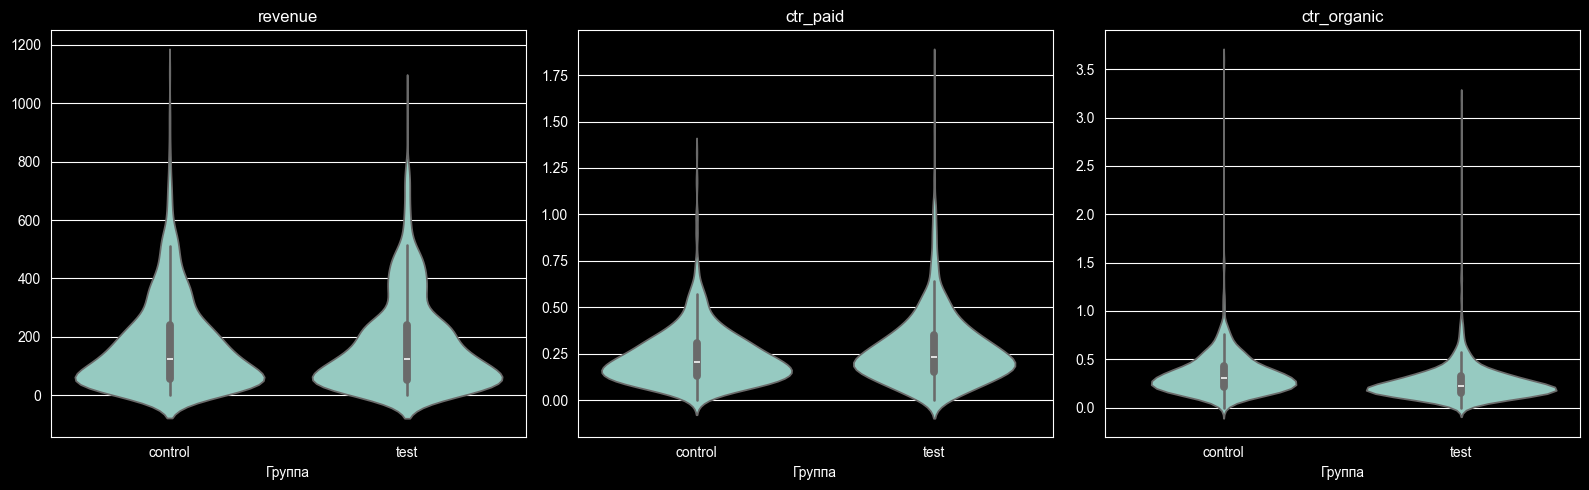

In [85]:
metrics = ['revenue', 'ctr_paid', 'ctr_organic']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for metric, ax in zip(metrics, axes):
    sns.violinplot(
        data=experiment_data,
        x='group',
        y=metric,
        ax=ax
    )

    ax.set_title(metric)
    ax.set_xlabel('Группа')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

### Предварительное сравнение групп

Визуальное сравнение распределений показывает, что распределение **revenue** в контрольной и тестовой группах существенно не изменилось.

Для **CTR платных элементов** наблюдается небольшой сдвиг распределения вверх в тестовой группе, что соответствует предполагаемому механизму воздействия изменения.

Одновременно с этим в тестовой группе наблюдается снижение **CTR органических элементов**. Поскольку данная метрика является guardrail-метрикой, необходимо отдельно проверить статистическую значимость этого изменения.

Для подтверждения наблюдаемых различий далее проведём статистические тесты.

In [86]:
metrics = ['revenue', 'ctr_paid', 'ctr_organic']

group_means = (
    experiment_data
    .groupby('group')[metrics]
    .mean()
    .round(3)
)

group_means

,revenue,ctr_paid,ctr_organic
group,,,
control,173.551,0.237,0.346
test,174.274,0.274,0.260


In [87]:
uplift = (
    group_means.loc['test'] /
    group_means.loc['control'] - 1
) * 100

uplift.round(2)

revenue         0.42
ctr_paid       15.61
ctr_organic   -24.86
dtype: float64

### Предварительные результаты эксперимента

В тестовой группе наблюдается рост **CTR платных элементов на 15.61%** относительно контрольной группы. Это соответствует предполагаемому механизму воздействия изменения.

При этом основная метрика — **выручка на пользователя — выросла лишь на 0.42%**, поэтому на уровне описательной статистики существенного бизнес-эффекта не наблюдается.

Одновременно **CTR органических элементов снизился на 24.86%**. Таким образом, изменение могло привести к перераспределению пользовательского внимания с органических элементов на платные.

На данном этапе нельзя утверждать, что наблюдаемые различия вызваны экспериментальным воздействием: необходимо проверить их статистическую значимость.

In [88]:
control_revenue = experiment_data[
    experiment_data['group'] == 'control'
]['revenue']

test_revenue = experiment_data[
    experiment_data['group'] == 'test'
]['revenue']

In [89]:
from scipy.stats import ttest_ind

ttest_ind(
    test_revenue,
    control_revenue,
    alternative='greater'
)

TtestResult(statistic=np.float64(0.10064378623302943), pvalue=np.float64(0.4599217105448494), df=np.float64(1981.0))

### Проверка основной метрики — Revenue

Для проверки роста выручки был проведён односторонний t-тест для двух независимых выборок.

**Гипотезы:**

- H₀: средняя выручка в тестовой группе не выше, чем в контрольной;
- H₁: средняя выручка в тестовой группе выше, чем в контрольной.

Получено:

- t-статистика = **0.101**;
- p-value = **0.460**;
- уровень значимости α = **0.05**.

Поскольку p-value > 0.05, нулевая гипотеза не отвергается. Статистически значимого роста выручки в тестовой группе обнаружено не было.

Наблюдаемый uplift выручки составляет всего **+0.42%**, однако имеющихся данных недостаточно, чтобы связать это увеличение с экспериментальным воздействием.

In [90]:
control_ctr_paid = experiment_data[
    experiment_data['group'] == 'control'
]['ctr_paid']

test_ctr_paid = experiment_data[
    experiment_data['group'] == 'test'
]['ctr_paid']

ttest_ind(
    test_ctr_paid,
    control_ctr_paid,
    alternative='greater'
)

TtestResult(statistic=np.float64(4.787671342990175), pvalue=np.float64(9.061292037650443e-07), df=np.float64(1981.0))

### Проверка прокси-метрики — CTR paid

Для проверки изменения CTR платных элементов был проведён односторонний t-тест для двух независимых выборок.

**Гипотезы:**

- H₀: средний CTR платных элементов в тестовой группе не выше, чем в контрольной;
- H₁: средний CTR платных элементов в тестовой группе выше, чем в контрольной.

Получено:

- t-статистика = **4.79**;
- p-value < **0.001**;
- уровень значимости α = **0.05**.

Поскольку p-value < 0.05, нулевая гипотеза отвергается. В тестовой группе наблюдается **статистически значимый рост CTR платных элементов**.

Средний CTR paid вырос с **0.237 до 0.274**, что соответствует относительному увеличению примерно на **15.61%**.

Таким образом, изменение расположения элементов действительно увеличило взаимодействие пользователей с платными элементами.

In [91]:
control_ctr_organic = experiment_data[
    experiment_data['group'] == 'control'
]['ctr_organic']

test_ctr_organic = experiment_data[
    experiment_data['group'] == 'test'
]['ctr_organic']

ttest_ind(
    test_ctr_organic,
    control_ctr_organic,
    alternative='less'
)

TtestResult(statistic=np.float64(-9.350272709558062), pvalue=np.float64(1.1400205275959941e-20), df=np.float64(1981.0))

### Проверка guardrail-метрики — CTR organic

Для проверки возможного негативного влияния изменения на взаимодействие пользователей с органическими элементами был проведён односторонний t-тест для двух независимых выборок.

**Гипотезы:**

- H₀: средний CTR органических элементов в тестовой группе не ниже, чем в контрольной;
- H₁: средний CTR органических элементов в тестовой группе ниже, чем в контрольной.

Получено:

- t-статистика = **−9.35**;
- p-value < **0.001**;
- уровень значимости α = **0.05**.

Поскольку p-value < 0.05, нулевая гипотеза отвергается. В тестовой группе наблюдается **статистически значимое снижение CTR органических элементов**.

Средний CTR organic снизился с **0.346 до 0.260**, что соответствует относительному снижению примерно на **24.86%**.

Таким образом, новое расположение элементов оказывает существенное негативное влияние на guardrail-метрику.

## Выводы и рекомендации для бизнеса

По результатам A/B-теста изменение расположения платных и органических элементов **не привело к статистически значимому росту выручки**.

### Результаты по основным метрикам

- **Revenue** вырос на **0.42%**: с 173.55 в контрольной группе до 174.27 в тестовой. Однако различие статистически незначимо (`p-value = 0.460`). Следовательно, оснований утверждать, что новый вариант интерфейса увеличивает выручку, нет.

- **CTR paid** вырос на **15.61%**: с 0.237 до 0.274. Различие статистически значимо (`p-value < 0.001`). Таким образом, изменение действительно увеличило взаимодействие пользователей с платными элементами.

- **CTR organic** снизился на **24.86%**: с 0.346 до 0.260. Снижение статистически значимо (`p-value < 0.001`), что свидетельствует о негативном влиянии изменения на guardrail-метрику.

### Итог

Продуктовая гипотеза подтвердилась **частично**: новое расположение элементов действительно увеличивает CTR платных элементов, однако этот рост **не приводит к статистически значимому увеличению выручки**. Одновременно наблюдается существенное снижение взаимодействия с органическими элементами.

Таким образом, **не рекомендуется раскатывать тестовый вариант на всех пользователей в текущем виде**.

Рекомендуется дополнительно исследовать причины, по которым рост CTR платных элементов не приводит к росту выручки, и протестировать другие варианты расположения элементов, позволяющие увеличить взаимодействие с платным контентом без существенного снижения CTR органических элементов.